# Exploratory Data Analysis & Data Cleaning — Credit Risk Behavioral Signals

This notebook explores the **Give Me Some Credit** dataset (150,000 borrowers, 10 features) to understand the financial behavior patterns that precede credit delinquency, and prepares a clean feature set for segmentation and modeling.

The goal isn't just descriptive — every observation drives a downstream decision. 
Key questions explored:
- What does the distribution of financial stress look like across borrowers?
- Which features are most associated with delinquency?
- Where is data missing, and what does that missingness tell us?
- Which features need transformation before modeling?

**Cleaning & engineering steps applied:**
- KNN imputation for `MonthlyIncome` (~32% missing after flagging near-zero values) and `NumberOfDependents`
- Log transformation of `MonthlyIncome` to address right skew
- Outlier capping on `RevolvingUtilizationOfUnsecuredLines` (clipped at 2.0)
- Binarization of past-due columns → `EverLate30`, `EverLate60`, `EverLate90`
- Binarization of `DebtRatio` → `DebtRatio_high` (debt obligations > monthly income)

**Output:** A cleaned `processed.csv` saved to `data/` for use in `02_segmentation.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data/cs-training.csv", index_col=0)

## 1. Load & inspect

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [5]:
df.shape

(150000, 11)

## 2. Target variable

In [6]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


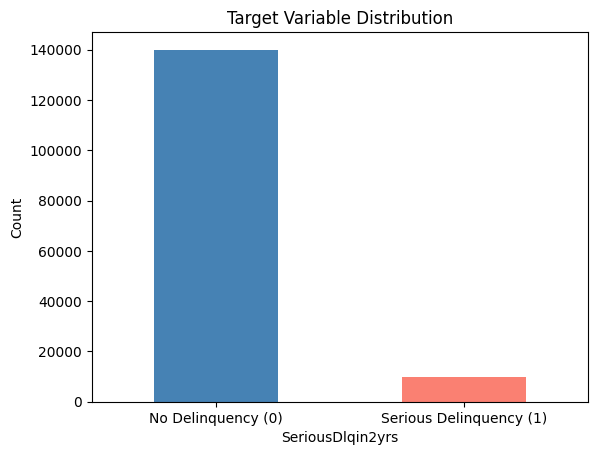

In [7]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Variable Distribution')
plt.xticks([0, 1], ['No Delinquency (0)', 'Serious Delinquency (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

### Class Imbalance
~6.7% of borrowers experienced serious delinquency — meaning the dataset is heavily imbalanced. A naive model that predicts "no delinquency" for everyone would be ~93% accurate but completely useless.

This means we'll need to account for imbalance in notebook 03 via class weighting or resampling (SMOTE) and evaluate using **precision/recall or AUC-ROC** rather than raw accuracy.

## 3. Missing data

In [8]:
print(df.isnull().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(609)

In [10]:
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values()

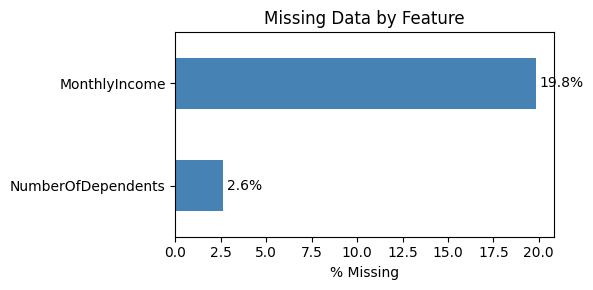

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
missing_pct.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Feature')
for i, v in enumerate(missing_pct):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

### Additional Data Quality Flag — MonthlyIncome Near-Zero Values

Beyond the ~20% of rows with `NaN` income, an additional ~12% of borrowers have a recorded `MonthlyIncome` below $1 (e.g. $0.20, $0.40). These values are almost certainly data entry errors — real monthly income of less than $1 is not plausible — but were not flagged as missing because they were stored as valid numeric values.

This issue was identified during segmentation (`02_segmentation.ipynb`), where one cluster was dominated by near-zero income borrowers, producing a mean `MonthlyIncome_log` of ~3.4 (≈ $30/month) that was clearly anomalous. These values are replaced with `NaN` below and included in KNN imputation alongside the original missing values, bringing total missing income to ~32% pre-imputation.

In [12]:
df.loc[df['MonthlyIncome'] < 1, 'MonthlyIncome'] = np.nan

In [13]:
print(f"Missing MonthlyIncome after flagging: {df['MonthlyIncome'].isnull().sum()}")

Missing MonthlyIncome after flagging: 31365


# 4. Distribution before imputation

In [14]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']
print(features)  # should be 10 columns

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [15]:
# cap outliers just for visualization (not changing the data)
plot_caps = {
    'RevolvingUtilizationOfUnsecuredLines': 2,
    'DebtRatio': 5,
    'MonthlyIncome': 20000,
    'NumberOfTime30-59DaysPastDueNotWorse': 10,
    'NumberOfTimes90DaysLate': 10,
    'NumberOfTime60-89DaysPastDueNotWorse': 10,
}


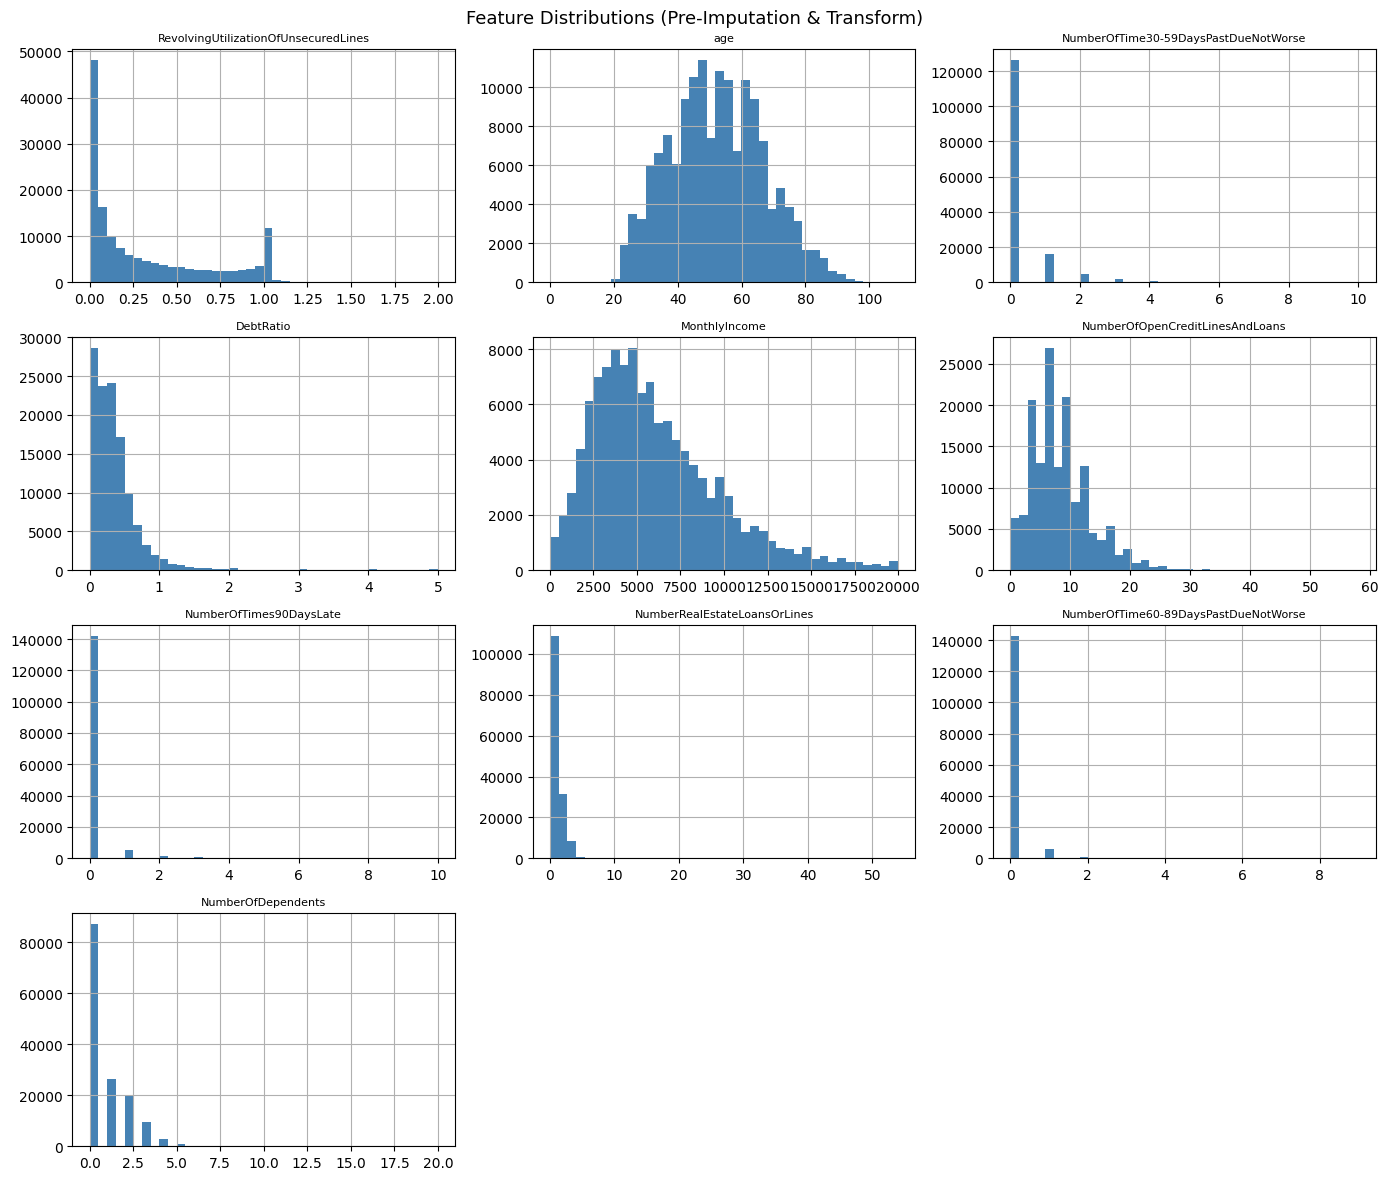

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    if col in plot_caps:
        data = data[data <= plot_caps[col]]
    data.hist(bins=40, ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=8)

# hide unused subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (Pre-Imputation & Transform)', fontsize=13)
plt.tight_layout()
plt.show()

## Observations

### Continuous Features:

1. **RevolvingUtilizationOfUnsecuredLines**
- Bimodal distribution: a large group of borrowers cluster near 0 (little to no credit usage) and a secondary spike at 1.0 (fully maxed out). This polarization makes utilization one of the strongest candidate features for segmentation — it almost directly maps to credit stress.

2. **MonthlyIncome**
- Right-skewed with most borrowers earning between $2,500–$10,000/month. The long tail suggests a small number of high earners pulling the mean up. Will apply a log transform (`log1p`) to normalize for modeling.

3. **DebtRatio**
- Similar right skew — most borrowers spend less than they earn (ratio < 1), but a meaningful tail extends above 1. Extreme values in the raw data (ratio > 5) are likely data entry errors rather than real financial behavior. Log transform applied.

4. **age**
- Roughly normal, peaking in the 50s. Irregular spikes may reflect age-rounding in data collection. No impossible values (e.g. age = 0) visible at this scale.

### Count / Frequency Features:

1. **NumberOfTime30-59, 60-89, 90+ DaysPastDue**
- All three are heavily zero-inflated — the vast majority of borrowers have never missed a payment. Raw counts carry little signal beyond the first occurrence, so these are converted to binary flags (`EverLate30`, `EverLate60`, `EverLate90`) for use in segmentation and modeling.

2. **NumberOfOpenCreditLinesAndLoans**
- The most normally distributed feature in the dataset, centered around 8–9 open lines. Suggests most borrowers have an established credit footprint.

3. **NumberRealEstateLoansOrLines**
- Heavily concentrated at 0–2, as expected. Most borrowers do not hold multiple mortgage products.

4. **NumberOfDependents**
- Right-skewed with most borrowers reporting 0 dependents. Used as-is — no transformation needed.

---

### Transformations Pending
| Feature | Transformation | Reason |
|---|---|---|
| `MonthlyIncome` | `log1p` | Right skew, large value range |
| `DebtRatio` | `log1p` | Right skew, outlier sensitivity |
| `RevolvingUtilization` | Capped at 2.0 | Values above 2 are likely data errors |
| Past-due columns (×3) | Binarized | Zero-inflated; count adds little signal |

## 5. Correlations

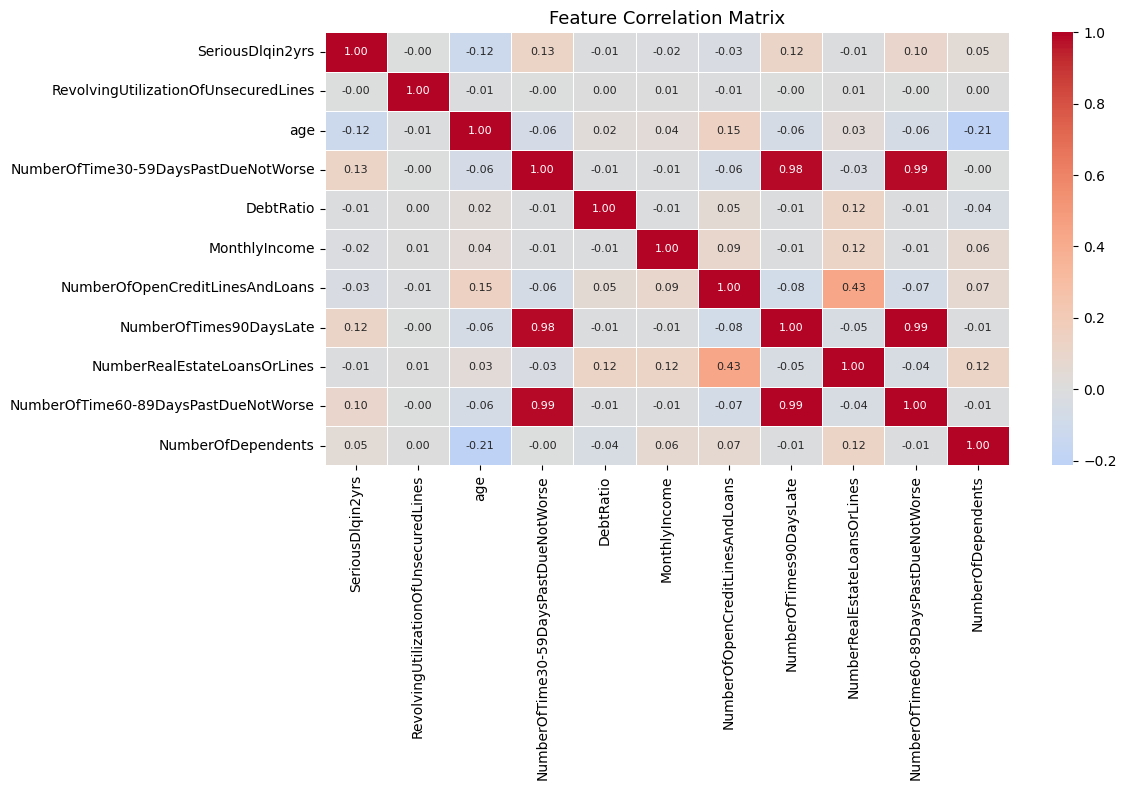

In [17]:
corr = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### Feature Correlation Matrix
The three past-due columns (`NumberOfTime30-59`, `60-89`, and `NumberOfTimes90DaysLate`) are almost perfectly correlated with each other (0.98–0.99) — borrowers who miss one payment tend to miss others across time windows. This multicollinearity means we should avoid using all three as independent features in modeling; one or a composite flag will suffice.

`NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines` are moderately correlated (0.43) — both reflect credit footprint size, which makes intuitive sense.

All other feature pairs are weakly correlated, suggesting the remaining features carry relatively independent signal.


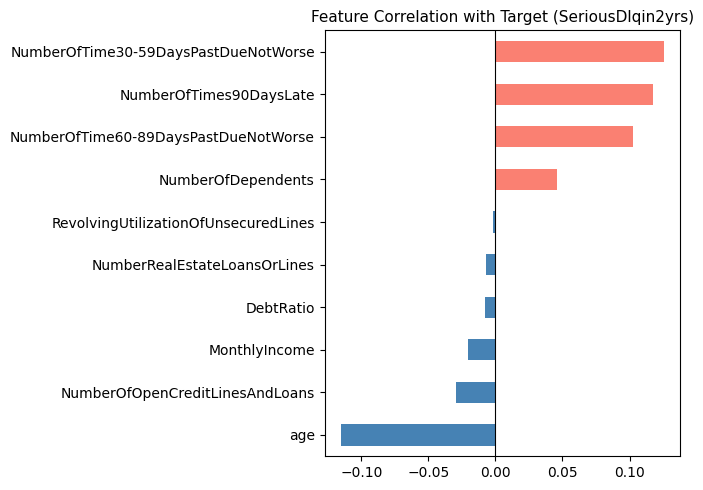

In [18]:
target_corr = df.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values()

plt.figure(figsize=(7, 5))
target_corr.plot(kind='barh', color=['salmon' if x > 0 else 'steelblue' for x in target_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (SeriousDlqin2yrs)', fontsize=11)
plt.tight_layout()
plt.show()

### Feature Correlation with Target
The strongest predictors of serious delinquency are:

- **Past-due history** — all three delinquency count columns correlate positively (~0.10–0.13), confirming that prior missed payments are the clearest signal of future default risk
- **age** — the strongest *negative* correlation (-0.12), meaning younger borrowers are meaningfully more likely to experience delinquency — consistent with thinner credit histories and lower financial stability early in life
- **NumberOfOpenCreditLinesAndLoans** — weakly negative (-0.03), suggesting borrowers with more open lines are slightly less likely to default
- **RevolvingUtilization, DebtRatio, MonthlyIncome** — surprisingly weak correlations individually, though utilization in particular may have non-linear effects not captured by Pearson correlation

Overall correlations with the target are low, which is typical for credit risk data. This motivates the use of non-linear models (decision trees) alongside logistic regression.

## 6. Scale + Impute missing data using KNN

In [19]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [20]:
imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df.columns)

In [21]:
df_imputed = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df.columns)

In [22]:
print(df_imputed.isnull().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [23]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [24]:
print(df['MonthlyIncome'].describe())
print(df_imputed['MonthlyIncome'].describe())

count    118635.00
mean       6762.09
std       14461.94
min           1.00
25%        3500.00
50%        5437.00
75%        8300.00
max     3008750.00
Name: MonthlyIncome, dtype: float64
count    150000.00
mean       5785.92
std       13076.29
min           1.00
25%        2637.15
50%        4644.50
75%        7500.00
max     3008750.00
Name: MonthlyIncome, dtype: float64


### Imputation Validation — MonthlyIncome
Post-imputation mean shifted from $6,762 to $5,786, and median from $5,437 to $4,645. The downward shift is more pronounced than in the initial imputation run, reflecting the additional ~12% of near-zero values flagged as missing — consistent with lower-income borrowers being more likely to have erroneous or unreported income entries. The minimum value is now $1, confirming all sub-$1 entries were successfully replaced. Distribution shape is preserved, validating the KNN imputation approach.

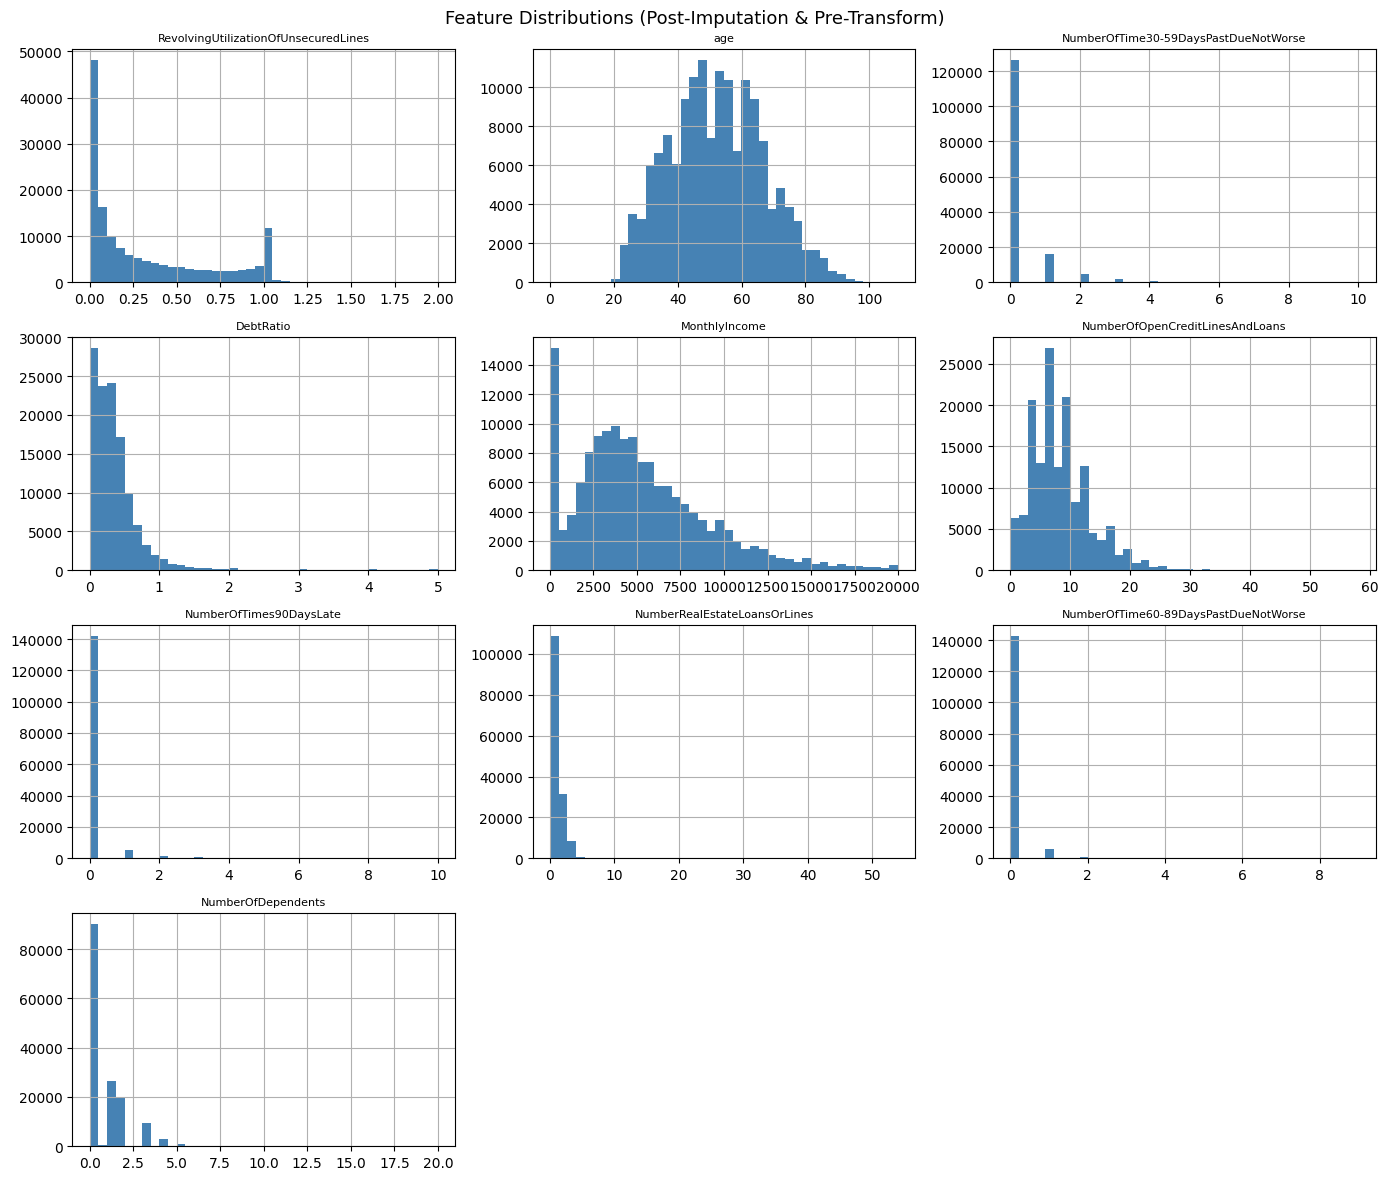

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_imputed[col].dropna()
    if col in plot_caps:
        data = data[data <= plot_caps[col]]
    data.hist(bins=40, ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=8)

# hide unused subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)


plt.suptitle('Feature Distributions (Post-Imputation & Pre-Transform)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Transform monthlyincome, debtratio, revolving utilization, and pastdue cols

In [26]:
# Log transform skewed features
df_imputed['MonthlyIncome_log'] = np.log1p(df_imputed['MonthlyIncome'])
df_imputed['DebtRatio_log'] = np.log1p(df_imputed['DebtRatio'])

In [27]:
# Cap utilization outliers
df_imputed['RevolvingUtilizationOfUnsecuredLines'] = df_imputed['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

In [28]:
# Binarize past-due columns
df_imputed['EverLate30'] = (df_imputed['NumberOfTime30-59DaysPastDueNotWorse'] > 0).astype(int)
df_imputed['EverLate60'] = (df_imputed['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)
df_imputed['EverLate90'] = (df_imputed['NumberOfTimes90DaysLate'] > 0).astype(int)

In [29]:
print(df_imputed.shape)

(150000, 16)


In [30]:
df_imputed.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_log,DebtRatio_log,EverLate30,EverLate60,EverLate90
0,1.00,0.77,45.00,2.00,0.80,9120.00,13.00,0.00,6.00,0.00,2.00,9.12,0.59,1,0,0
1,0.00,0.96,40.00,0.00,0.12,2600.00,4.00,0.00,0.00,0.00,1.00,7.86,0.12,0,0,0
2,0.00,0.66,38.00,1.00,0.09,3042.00,2.00,1.00,0.00,0.00,0.00,8.02,0.08,1,0,1
3,0.00,0.23,30.00,0.00,0.04,3300.00,5.00,0.00,0.00,0.00,0.00,8.10,0.04,0,0,0
4,0.00,0.91,49.00,1.00,0.02,63588.00,7.00,0.00,1.00,0.00,0.00,11.06,0.02,1,0,0


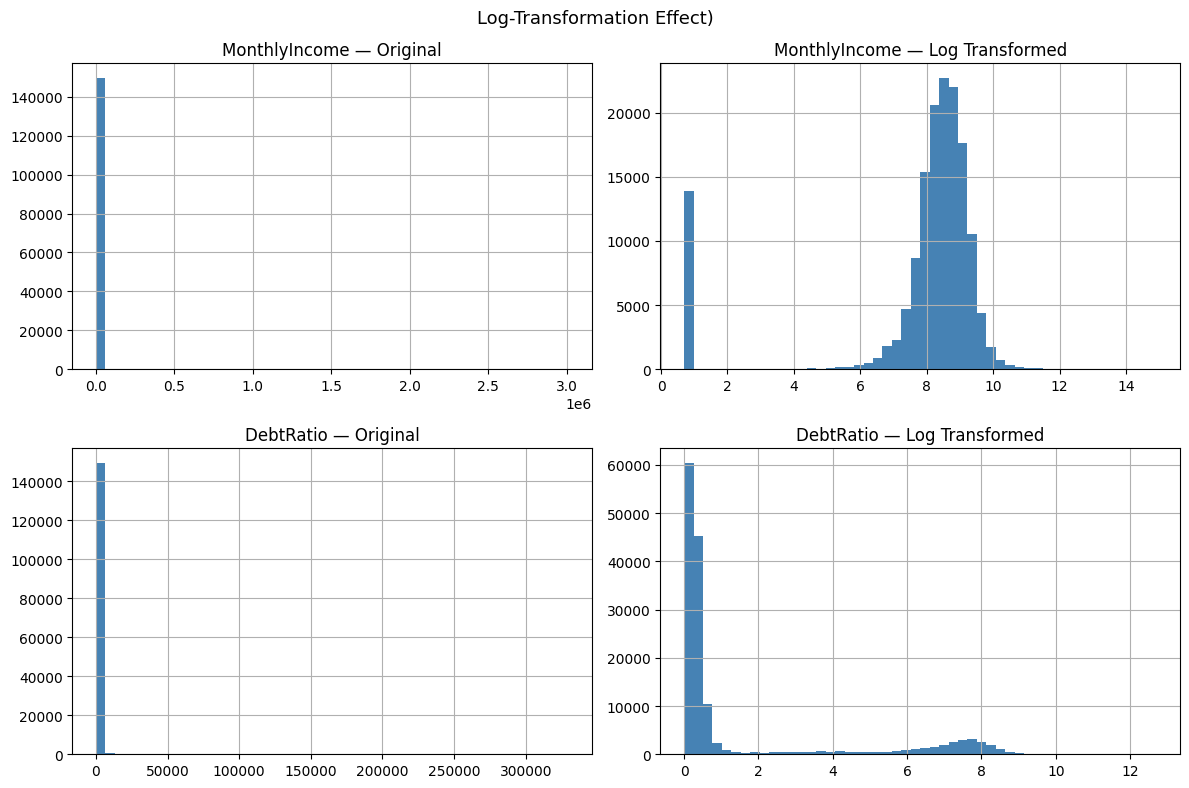

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_imputed['MonthlyIncome'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='none')
axes[0,0].set_title('MonthlyIncome — Original')

df_imputed['MonthlyIncome_log'].hist(bins=50, ax=axes[0,1], color='steelblue', edgecolor='none')
axes[0,1].set_title('MonthlyIncome — Log Transformed')

df_imputed['DebtRatio'].hist(bins=50, ax=axes[1,0], color='steelblue', edgecolor='none')
axes[1,0].set_title('DebtRatio — Original')

df_imputed['DebtRatio_log'].hist(bins=50, ax=axes[1,1], color='steelblue', edgecolor='none')
axes[1,1].set_title('DebtRatio — Log Transformed')

plt.suptitle('Log-Transformation Effect)', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
df_imputed['DebtRatio_high'] = (df_imputed['DebtRatio'] > 1).astype(int)
print(df_imputed['DebtRatio_high'].value_counts())
print(df_imputed['DebtRatio_high'].value_counts(normalize=True).round(3))

DebtRatio_high
0    114863
1     35137
Name: count, dtype: int64
DebtRatio_high
0   0.77
1   0.23
Name: proportion, dtype: float64


**MonthlyIncome** — log transform largely effective, converting a heavily right-skewed distribution (raw range $0–$3M) into an approximately normal distribution centered around log(~$8,000). A residual spike at 0–1 remains, likely reflecting borrowers who reported zero or near-zero income — possibly unemployed, retired, or relying on non-wage income sources not captured by this field. Missing values (~20% of rows) were imputed using KNN prior to transformation. The imputed values skewed lower than the observed mean ($5,664 vs $6,670), consistent with lower-income borrowers being less likely to report income — validating the use of KNN over simple median imputation.

**DebtRatio** — log transform was ineffective due to severe zero-inflation; `log1p(0) = 0` preserves the spike at zero. Instead, engineered a binary feature `DebtRatio_high` where 1 indicates monthly debt obligations exceed monthly income. 23% of borrowers fall into this category, making it a meaningful financial stress indicator rather than a rare edge case.

## 8. Summary

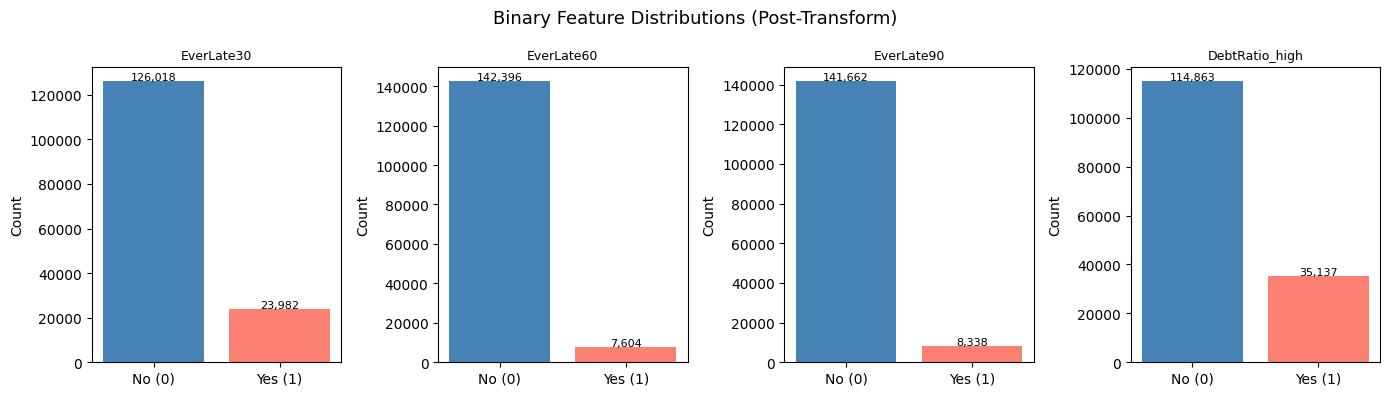

In [33]:
binary_cols = ['EverLate30', 'EverLate60', 'EverLate90', 'DebtRatio_high']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, col in enumerate(binary_cols):
    counts = df_imputed[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], counts, color=['steelblue', 'salmon'], edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 500, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Binary Feature Distributions (Post-Transform)', fontsize=13)
plt.tight_layout()
plt.show()

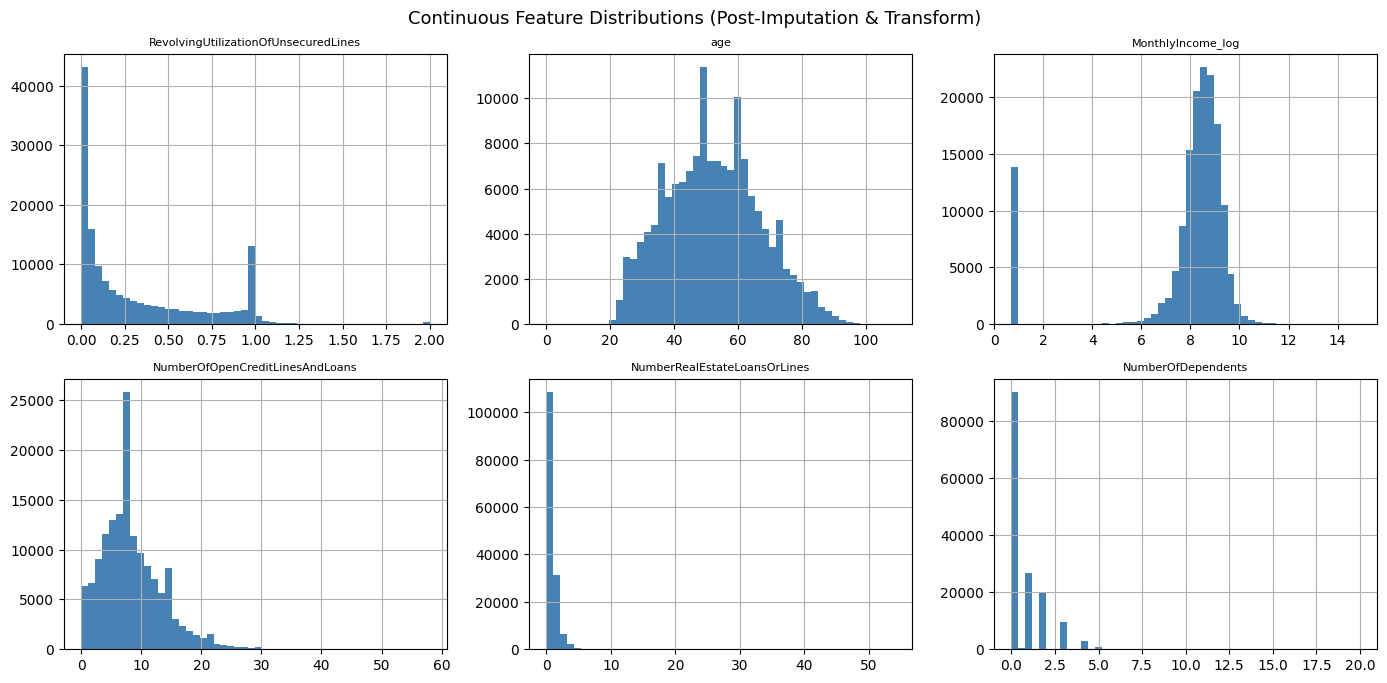

In [34]:
continuous_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome_log', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    df_imputed[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=8)

for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Feature Distributions (Post-Imputation & Transform)', fontsize=13)
plt.tight_layout()
plt.show()

## Post-Transformation Feature Summary

### Binary Indicators

| Feature | Yes (1) | No (0) | % Yes |
|---|---|---|---|
| EverLate30 | 23,982 | 126,018 | 16.0% |
| EverLate60 | 7,604 | 142,396 | 5.1% |
| EverLate90 | 8,338 | 141,662 | 5.6% |
| DebtRatio_high | 35,137 | 114,863 | 23.4% |

1. **EverLate30** has the highest positive rate (16%) — 30-59 day delinquencies are the most common form of missed payment, likely capturing borrowers in early financial stress before it escalates.

2. **EverLate60 and EverLate90** are much rarer (5–6%), consistent with most borrowers who slip up once managing to recover before hitting deeper delinquency.

3. **DebtRatio_high** at 23.4% is the most prevalent risk flag in the dataset — nearly 1 in 4 borrowers carry debt obligations exceeding their monthly income, making this a meaningful segmentation variable.

### Continuous Features (Post-Imputation & Transform)

| Feature | Treatment | Notes |
|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | Capped at 2.0 | Bimodal: spike near 0 and at 1.0 reflects two distinct borrower behaviors |
| age | None | Roughly normal, peaks in 50s |
| MonthlyIncome | Log transformed | Normalized from heavily right-skewed; residual spike at 0 reflects zero/near-zero income reporters |
| NumberOfOpenCreditLinesAndLoans | None | Roughly normal, centered at 8–9 |
| NumberRealEstateLoansOrLines | None | Zero-inflated count, low range |
| NumberOfDependents | None | Zero-inflated count, low range |

## 9. Export data

In [35]:
df_imputed.to_csv('data/processed.csv')